## Setup Comparison

Setups 0-3 in order:

![Schematic of measurement setup 1](figures\all_setups.png)

Setup 0:
Setup 0:
| Parameter | Meaning |
|-----------|-------|
| $η_{PD_1}$    | Quantum efficiency of $PD_1$     |
| $η_{PD_2}$    | Quantum efficiency of $PD_2$     |
| $η_{FC}$      | Transmissivity of $FC$           |
| $\alpha$      | LO coherent amplitude            |
| $\phi$        | LO phase                         |
| $r$           | Squeezing parameter              |
| $\theta$      | Squeezing angle                  |
| $\Delta\omega$ | Frequency shift of the LO arm   |
| $\omega_0$    | Carrier (centre) frequency       |
| $B$           | PD measurement bandwith          |
| $B_{sqz}$     | Squeezing bandwidth ($B_{sqz} \geq \Delta\omega + B$) |

Setup 1:
| Parameter | Meaning |
|-----------|-------|
| $η_{PD_1}$    | Quantum efficiency of $PD_1$     |
| $η_{PD_2}$    | Quantum efficiency of $PD_2$     |
| $η_{FC_1}$    | Transmissivity of $FC_1$         |
| $η_{FC_2}$    | Transmissivity of $FC_2$         |
| $\alpha$      | LO coherent amplitude            |
| $\phi$        | LO phase                         |
| $r$           | Squeezing parameter              |
| $\theta$      | Squeezing angle                  |
| $\tau$        | Time delay of lower arm in FFR   |
| $\omega_0$    | Carrier (centre) frequency       |
| $B$           | PD measurement bandwith          |

Setup 2:
| Parameter | Meaning |
|-----------|-------|
| $η_{PD_1}$    | Quantum efficiency of $PD_1$     |
| $η_{PD_2}$    | Quantum efficiency of $PD_2$     |
| $η_{FC_1}$    | Transmissivity of $FC_1$         |
| $η_{FC_2}$    | Transmissivity of $FC_2$         |
| $\eta_{inj}$  | Injection efficiency of the second squeezed field |
| $\alpha$      | LO coherent amplitude            |
| $\phi$        | LO phase                         |
| $r$           | Squeezing parameter              |
| $\theta$      | Squeezing angle                  |
| $r'$           | Injected squeezing parameter              |
| $\theta'$      | Injected squeezing angle                  |
| $\tau$        | Time delay of lower arm in FFR   |
| $\omega_0$    | Carrier (centre) frequency       |
| $B$           | PD measurement bandwith          |

Setup 3:
| Parameter | Meaning |
|-----------|-------|
| $η_{PD_1}$    | Quantum efficiency of $PD_1$     |
| $η_{PD_2}$    | Quantum efficiency of $PD_2$     |
| $η_{FC_1}$    | Transmissivity of $FC_1$         |
| $η_{FC_2}$    | Transmissivity of $FC_2$         |
| $η_{FC_3}$    | Transmissivity of $FC_3$         |
| $\alpha$      | LO coherent amplitude            |
| $\phi$        | LO phase                         |
| $r$           | Squeezing parameter              |
| $\theta$      | Squeezing angle                  |
| $\tau$        | Time delay of lower arm in first FFR   |
| $\tau'$        | Time delay of lower arm in second FFR   |
| $\omega_0$    | Carrier (centre) frequency       |
| $B$           | PD measurement bandwith          |

In [ ]:
### Base imports

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
### Standard parameters
c = 299792458

params = {
    "omega_0" : (c*2*np.pi) / 1550e-9,  #1550 nm wavelength
    "B" : 2e9,                          #Gigahertz bandwidth
    "n_fibre": 1.6,                     #Optical fibre refractive index
}

## Setup 0:

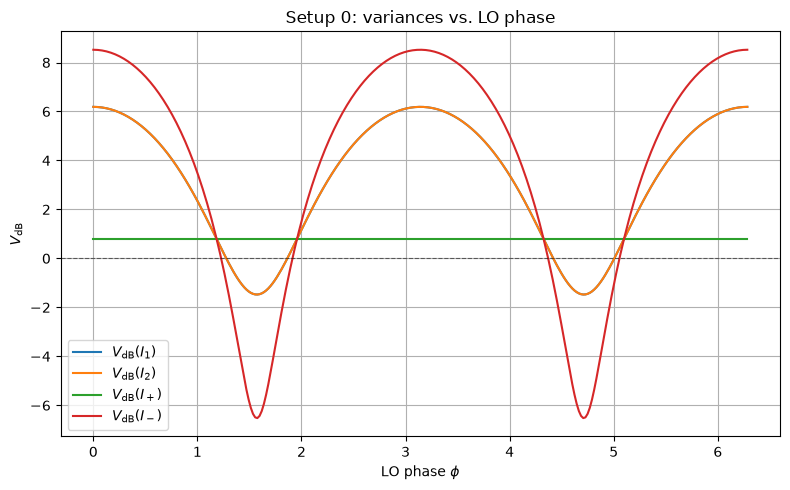

In [20]:
### Variances vs. LO phase

from formulas.general import s0_VdB_I1, s0_VdB_I2, s0_VdB_Ip, s0_VdB_Im

# Setup 0: alpha, phi, eta_FC, eta_PD1, eta_PD2, r, theta, Bsqz, domega, t
alpha   = 1.0
eta_FC  = 0.5
eta_PD1 = 0.95
eta_PD2 = 0.95
r       = 1.0
theta   = 0.0
Bsqz    = 0.1
domega  = 1.0
t       = 0.0

phi = np.linspace(0, 2*np.pi, 300)

VdB_I1 = [s0_VdB_I1(alpha, p, eta_FC, eta_PD1, eta_PD2, r, theta, Bsqz, domega, t) for p in phi]
VdB_I2 = [s0_VdB_I2(alpha, p, eta_FC, eta_PD1, eta_PD2, r, theta, Bsqz, domega, t) for p in phi]
VdB_Ip = [s0_VdB_Ip(alpha, p, eta_FC, eta_PD1, eta_PD2, r, theta, Bsqz, domega, t) for p in phi]
VdB_Im = [s0_VdB_Im(alpha, p, eta_FC, eta_PD1, eta_PD2, r, theta, Bsqz, domega, t) for p in phi]

plt.figure(figsize=(8, 5))
plt.plot(phi, VdB_I1, label=r"$V_{\mathrm{dB}}(I_1)$")
plt.plot(phi, VdB_I2, label=r"$V_{\mathrm{dB}}(I_2)$")
plt.plot(phi, VdB_Ip, label=r"$V_{\mathrm{dB}}(I_+)$")
plt.plot(phi, VdB_Im, label=r"$V_{\mathrm{dB}}(I_-)$")
plt.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
plt.xlabel(r"LO phase $\phi$")
plt.ylabel(r"$V_{\mathrm{dB}}$")
plt.title("Setup 0: variances vs. LO phase")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

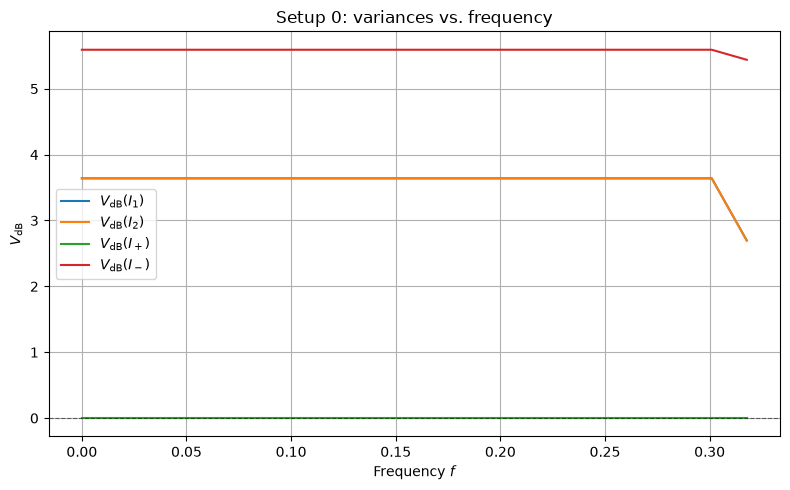

In [16]:
### Variances vs. frequency

from formulas.general import s0_VdB_I1_f, s0_VdB_I2_f, s0_VdB_Ip_f, s0_VdB_Im_f

# Setup 0: alpha, phi, eta_FC, eta_PD1, eta_PD2, r, theta, Bsqz, domega, t
alpha   = 1.0
phi     = 0.0
eta_FC  = 0.5
eta_PD1 = 0.95
eta_PD2 = 0.95
r       = 1.0
theta   = 0.0
Bsqz    = 2.0
domega  = 0.01
t       = 0.0

f = np.linspace(0, 5, 300)
P = (alpha, phi, eta_FC, eta_PD1, eta_PD2, r, theta, Bsqz, domega, t)

VdB_I1 = [s0_VdB_I1_f(fi, *P) for fi in f]
VdB_I2 = [s0_VdB_I2_f(fi, *P) for fi in f]
VdB_Ip = [s0_VdB_Ip_f(fi, *P) for fi in f]
VdB_Im = [s0_VdB_Im_f(fi, *P) for fi in f]

plt.figure(figsize=(8, 5))
plt.plot(f, VdB_I1, label=r"$V_{\mathrm{dB}}(I_1)$")
plt.plot(f, VdB_I2, label=r"$V_{\mathrm{dB}}(I_2)$")
plt.plot(f, VdB_Ip, label=r"$V_{\mathrm{dB}}(I_+)$")
plt.plot(f, VdB_Im, label=r"$V_{\mathrm{dB}}(I_-)$")
plt.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
plt.xlabel(r"Frequency $f$")
plt.ylabel(r"$V_{\mathrm{dB}}$")
plt.title("Setup 0: variances vs. frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Setup 1:

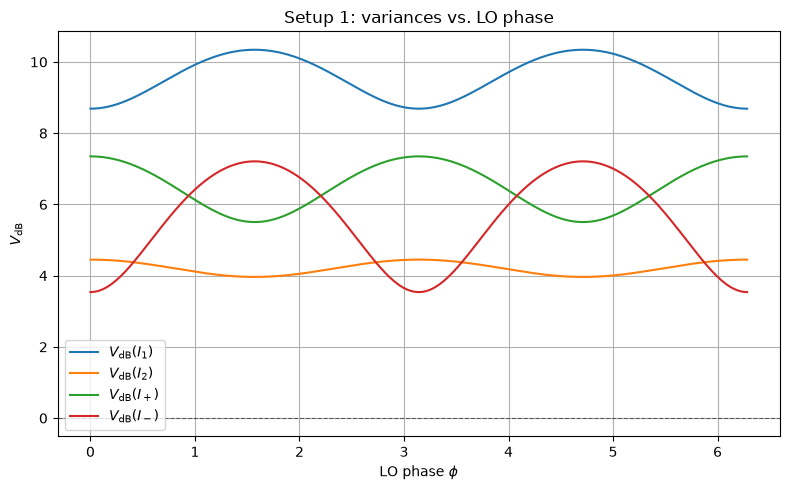

In [ ]:
### Variances vs. LO phase

from formulas.general import s1_VdB_I1, s1_VdB_I2, s1_VdB_Ip, s1_VdB_Im

# Setup 1: alpha, phi, eta_FC1, eta_FC2, eta_PD1, eta_PD2, tau, r, theta, B, omega0
alpha   = 1.0
eta_FC1 = 0.5
eta_FC2 = 0.5
eta_PD1 = 0.95
eta_PD2 = 0.95
tau     = 1
r       = 1.0
theta   = 0.0
B       = 2.0
omega0  = 1.0

phi = np.linspace(0, 2*np.pi, 300)

VdB_I1 = [s1_VdB_I1(alpha, p, eta_FC1, eta_FC2, eta_PD1, eta_PD2, tau, r, theta, B, omega0) for p in phi]
VdB_I2 = [s1_VdB_I2(alpha, p, eta_FC1, eta_FC2, eta_PD1, eta_PD2, tau, r, theta, B, omega0) for p in phi]
VdB_Ip = [s1_VdB_Ip(alpha, p, eta_FC1, eta_FC2, eta_PD1, eta_PD2, tau, r, theta, B, omega0) for p in phi]
VdB_Im = [s1_VdB_Im(alpha, p, eta_FC1, eta_FC2, eta_PD1, eta_PD2, tau, r, theta, B, omega0) for p in phi]

plt.figure(figsize=(8, 5))
plt.plot(phi, VdB_I1, label=r"$V_{\mathrm{dB}}(I_1)$")
plt.plot(phi, VdB_I2, label=r"$V_{\mathrm{dB}}(I_2)$")
plt.plot(phi, VdB_Ip, label=r"$V_{\mathrm{dB}}(I_+)$")
plt.plot(phi, VdB_Im, label=r"$V_{\mathrm{dB}}(I_-)$")
plt.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
plt.xlabel(r"LO phase $\phi$")
plt.ylabel(r"$V_{\mathrm{dB}}$")
plt.title("Setup 1: variances vs. LO phase")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

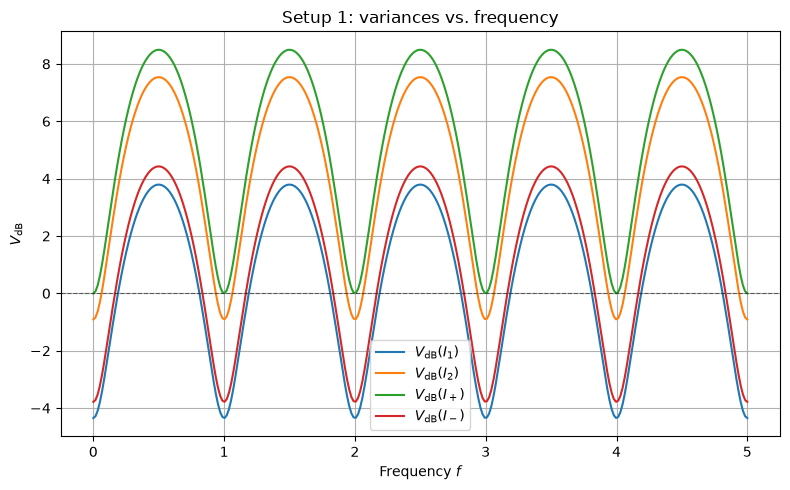

In [6]:
### Variances vs. frequency

from formulas.general import s1_VdB_I1_f, s1_VdB_I2_f, s1_VdB_Ip_f, s1_VdB_Im_f

# Setup 1: alpha, phi, eta_FC1, eta_FC2, eta_PD1, eta_PD2, tau, r, theta, B, omega0
alpha   = 1.0
phi     = 0.0
eta_FC1 = 0.5
eta_FC2 = 0.5
eta_PD1 = 0.95
eta_PD2 = 0.95
tau     = 1.0
r       = 1.0
theta   = 0.0
B       = 2.0
omega0  = 1.0

f = np.linspace(0, 5, 300)
P = (alpha, phi, eta_FC1, eta_FC2, eta_PD1, eta_PD2, tau, r, theta, B, omega0)

VdB_I1 = [s1_VdB_I1_f(fi, *P) for fi in f]
VdB_I2 = [s1_VdB_I2_f(fi, *P) for fi in f]
VdB_Ip = [s1_VdB_Ip_f(fi, *P) for fi in f]
VdB_Im = [s1_VdB_Im_f(fi, *P) for fi in f]

plt.figure(figsize=(8, 5))
plt.plot(f, VdB_I1, label=r"$V_{\mathrm{dB}}(I_1)$")
plt.plot(f, VdB_I2, label=r"$V_{\mathrm{dB}}(I_2)$")
plt.plot(f, VdB_Ip, label=r"$V_{\mathrm{dB}}(I_+)$")
plt.plot(f, VdB_Im, label=r"$V_{\mathrm{dB}}(I_-)$")
plt.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
plt.xlabel(r"Frequency $f$")
plt.ylabel(r"$V_{\mathrm{dB}}$")
plt.title("Setup 1: variances vs. frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

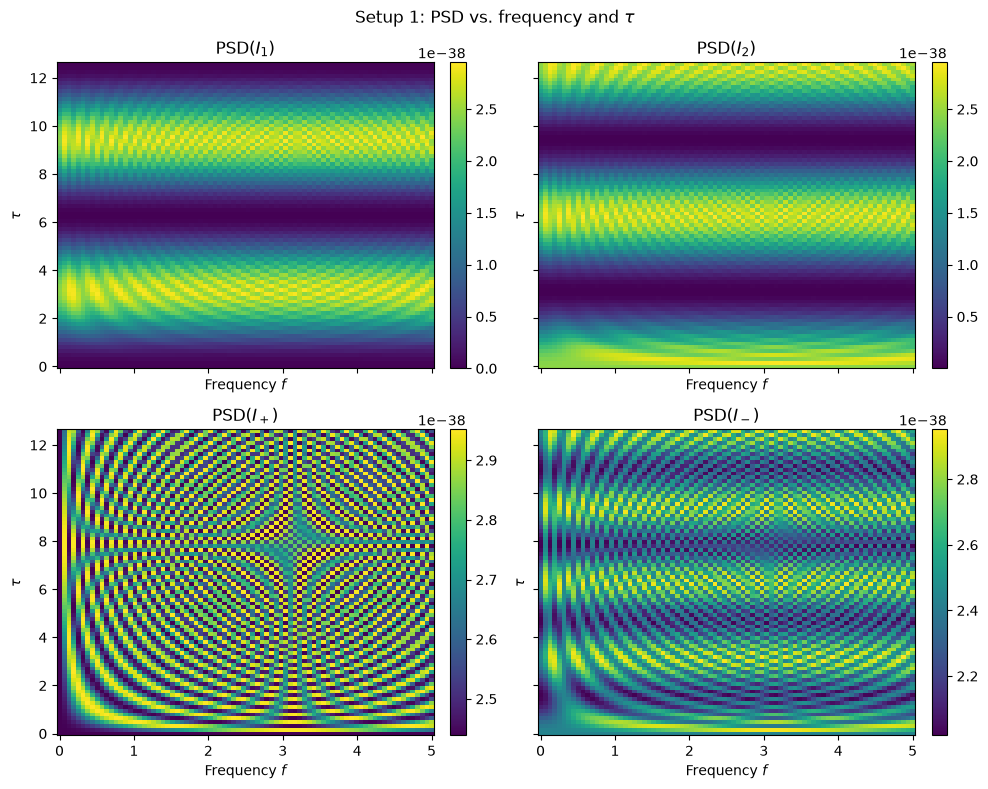

In [ ]:
### PSD heatmaps vs. frequency and tau

from formulas.setup_1 import PSD_I1, PSD_I2, PSD_Ip, PSD_Im

# Fixed params: alpha, phi, eta_FC1, eta_FC2, eta_PD1, eta_PD2, r, theta, B, omega0
alpha   = 1.0
phi     = 0.0
eta_FC1 = 0.5
eta_FC2 = 0.5
eta_PD1 = 0.95
eta_PD2 = 0.95
r       = 0.1
theta   = 0.0
B       = 2.0
omega0  = 1.0

f_vals   = np.linspace(0, 5, 80)
tau_vals = np.linspace(0, 4*np.pi/omega0, 80)

def grid_PSD(psd_fn):
    Z = np.empty((len(tau_vals), len(f_vals)))
    for i, tau in enumerate(tau_vals):
        for j, f in enumerate(f_vals):
            Z[i, j] = psd_fn(f, alpha, phi, eta_FC1, eta_FC2, eta_PD1, eta_PD2,
                             tau, r, theta, B, omega0)
    return Z

Z_I1 = grid_PSD(PSD_I1)
Z_I2 = grid_PSD(PSD_I2)
Z_Ip = grid_PSD(PSD_Ip)
Z_Im = grid_PSD(PSD_Im)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
panels = [
    (axes[0, 0], Z_I1, r"PSD$(I_1)$"),
    (axes[0, 1], Z_I2, r"PSD$(I_2)$"),
    (axes[1, 0], Z_Ip, r"PSD$(I_+)$"),
    (axes[1, 1], Z_Im, r"PSD$(I_-)$"),
]

for ax, Z, title in panels:
    im = ax.pcolormesh(f_vals, tau_vals, Z, shading="auto", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel(r"Frequency $f$")
    ax.set_ylabel(r"$\tau$")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Setup 1: PSD vs. frequency and " + r"$\tau$")
fig.tight_layout()
plt.show()

## Setup 2

c:\Users\axels\Desktop\SK2004\Code\two-mode-squeezing\simulation\formulas\general.py:69: RuntimeWarning: divide by zero encountered in scalar divide
  return 10*np.log10(V/V_r0)


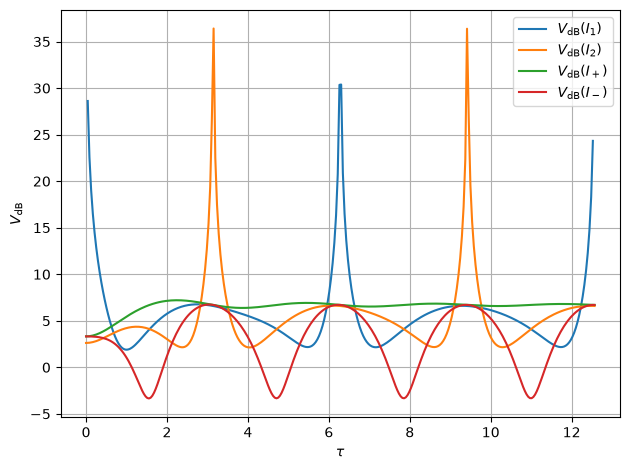

In [11]:
from formulas.general import s2_VdB_I1, s2_VdB_I2, s2_VdB_Ip, s2_VdB_Im

alpha   = 5.0
phi     = 0.0
eta_FC1 = 0.5
eta_FC2 = 0.5
eta_inj = 0.5
eta_PD1 = 0.95
eta_PD2 = 0.95
r       = 1.0
theta   = 0.0
rp      = 0.5
thetap  = 0.0
B       = 2.0
omega0  = 1.0


tau = np.linspace(0, 4*np.pi/omega0, 300)
head = (alpha, phi, eta_FC1, eta_FC2, eta_inj, eta_PD1, eta_PD2)
tail = (r, theta, rp, thetap, B, omega0)

for fn, lab in [(s2_VdB_I1, r"I_1"), (s2_VdB_I2, r"I_2"), (s2_VdB_Ip, r"I_+"), (s2_VdB_Im, r"I_-")]:
    plt.plot(tau, [fn(*head, t, *tail) for t in tau], label=rf"$V_{{\mathrm{{dB}}}}({lab})$")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$V_{\mathrm{dB}}$")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Setup 3

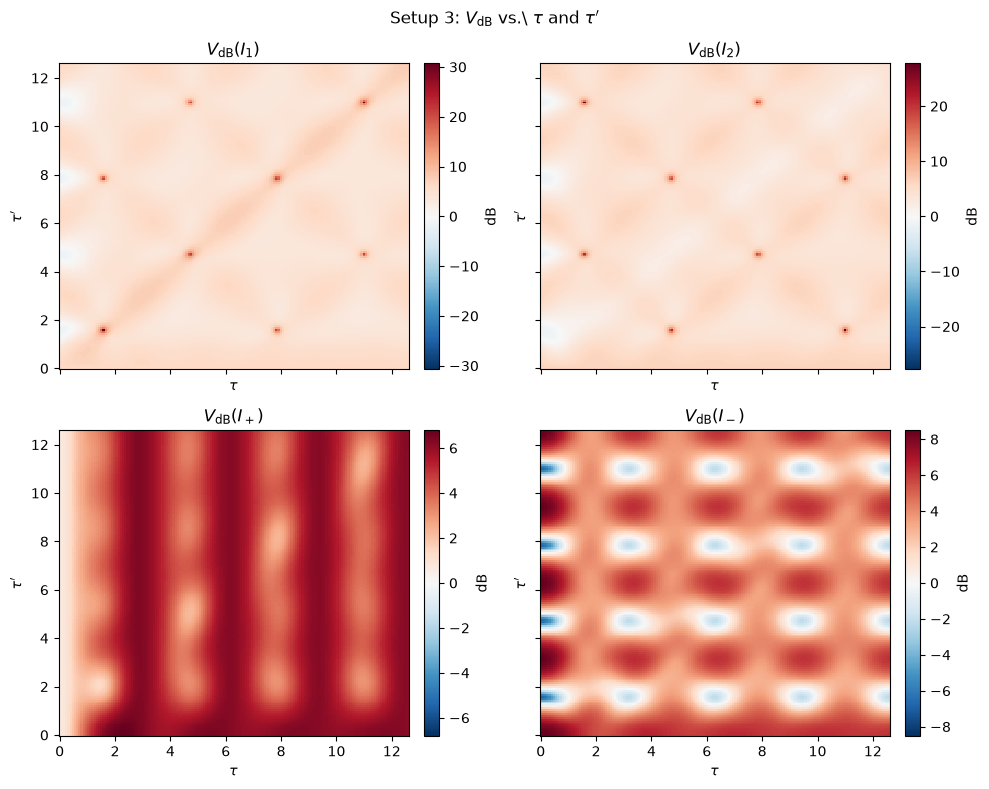

In [14]:
### V_dB vs. tau and tau' (Setup 3)

from formulas.general import s3_VdB_I1, s3_VdB_I2, s3_VdB_Ip, s3_VdB_Im

alpha    = 5.0
phi      = 0.0
eta_FC1  = 0.5
eta_FC2  = 0.5
eta_FC3  = 0.5
eta_PD1  = 0.95
eta_PD2  = 0.95
r        = 1.0
theta    = 0.0
B        = 2.0
omega0   = 1.0

tau_vals  = np.linspace(0, 4 * np.pi / omega0, 160)
taup_vals = np.linspace(0, 4 * np.pi / omega0, 160)

head = (alpha, phi, eta_FC1, eta_FC2, eta_FC3, eta_PD1, eta_PD2)
tail = (r, theta, B, omega0)

def VdB_grid(fn):
    Z = np.empty((tau_vals.size, taup_vals.size))
    for i, t in enumerate(tau_vals):
        for j, tp in enumerate(taup_vals):
            Z[i, j] = fn(*head, t, tp, *tail)
    return Z

panels = [
    (s3_VdB_I1, r"$V_{\mathrm{dB}}(I_1)$"),
    (s3_VdB_I2, r"$V_{\mathrm{dB}}(I_2)$"),
    (s3_VdB_Ip, r"$V_{\mathrm{dB}}(I_+)$"),
    (s3_VdB_Im, r"$V_{\mathrm{dB}}(I_-)$"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
for ax, (fn, title) in zip(axes.ravel(), panels):
    Z = VdB_grid(fn)
    vlim = max(np.nanmax(np.abs(Z)), 1e-3)
    im = ax.pcolormesh(
        tau_vals, taup_vals, Z.T,
        shading="auto", cmap="RdBu_r", vmin=-vlim, vmax=vlim,
    )
    ax.set_title(title)
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\tau'$")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=r"dB")

fig.suptitle(r"Setup 3: $V_{\mathrm{dB}}$ vs.\ $\tau$ and $\tau'$")
fig.tight_layout()
plt.show()